# Sanity check: quijote3gpch nbody vs fastpm_charm6 halo catalogs (L3000-N384, lhid=2000)

Direct comparison of a full N-body run and its `fastpm_charm6` emulator counterpart.
Same cosmology, same lhid, same box (L=3000 Mpc/h, N=384); only the solver differs.
N-body is treated as ground truth.

Scale factor: a = 0.666667 (z = 0.5).

Checks: (1) file structure & halo counts, (2) halo mass function comparison,
(3) projected spatial distribution, (4) velocity PDFs, (5) concentration PDFs,
(6) cumulative number density N(>M), (7) halo power spectrum vs CAMB.

Run with the **`cmass`** conda env.

In [ ]:
import os
from os.path import join
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

BASEDIR_NBODY = '/work/hdd/bdne/maho3/cmass-ili/quijote3gpch/nbody/L3000-N384'
BASEDIR_FASTPM = '/work/hdd/bdne/maho3/cmass-ili/quijote3gpch/fastpm_charm6/L3000-N384'
FIGDIR = '/u/maho3/git/ltu-gobig-notes/experiments/2026-07-09_sanity_nbody_vs_fastpm_L3000/figures'
os.makedirs(FIGDIR, exist_ok=True)

LHID = '2000'
L = 3000.0   # Mpc/h
V = L ** 3
A_TARGET = 0.666667

SUITES = [
    ('nbody',         BASEDIR_NBODY,  'C0', '-'),
    ('fastpm_charm6', BASEDIR_FASTPM, 'C1', '--'),
]
print(f'L={L} Mpc/h,  V={V:.2e} (Mpc/h)^3,  lhid={LHID},  a={A_TARGET}')
print(f'FIGDIR={FIGDIR}')

L=3000.0 Mpc/h,  V=2.70e+10 (Mpc/h)^3,  lhid=2000,  a=0.666667
FIGDIR=/u/maho3/git/ltu-gobig-notes/experiments/2026-07-09_sanity_nbody_vs_fastpm_L3000/figures


In [3]:
# --- helpers ---------------------------------------------------------------
def find_snap_key(hdf5_path, a_target):
    """Return the snapshot group key closest to a_target."""
    with h5py.File(hdf5_path, 'r') as f:
        keys = list(f.keys())
    return min(keys, key=lambda k: abs(float(k) - a_target))


def load_halos(basedir, lhid):
    """Return (mass, pos, vel, conc, snap_key) for the closest snapshot to A_TARGET."""
    p = join(basedir, str(lhid), 'halos.h5')
    key = find_snap_key(p, A_TARGET)
    with h5py.File(p, 'r') as f:
        g = f[key]
        mass = g['mass'][:]
        pos = g['pos'][:]
        vel = g['vel'][:]
        conc = g['concentration'][:]
    return mass, pos, vel, conc, key


def load_cosmo(basedir, lhid):
    """Return [Omega_m, Omega_b, h, n_s, sigma8] from config.yaml."""
    with open(join(basedir, str(lhid), 'config.yaml')) as f:
        cfg = yaml.safe_load(f)
    return np.array(cfg['nbody']['cosmo'])


def mass_function(mass, volume, n_bins=40, m_min=None, m_max=None):
    """Compute dN/dlogM/V in logarithmic mass bins."""
    m_min = m_min or mass.min() * 0.9
    m_max = m_max or mass.max() * 1.1
    log_edges = np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    counts, _ = np.histogram(np.log10(mass), bins=log_edges)
    log_centers = 0.5 * (log_edges[:-1] + log_edges[1:])
    dlogM = log_edges[1] - log_edges[0]
    dn_dlogM_dV = counts / (dlogM * volume)
    return 10 ** log_centers, dn_dlogM_dV

## 1. File structure, halo counts & cosmology

In [4]:
print(f"{'suite':>16} | {'snap key':>10} | {'N_halos':>12} | n [h/Mpc]^3")
print('-' * 60)
for label, basedir, *_ in SUITES:
    p = join(basedir, LHID, 'halos.h5')
    assert os.path.isfile(p), f'MISSING: {p}'
    m, pos, vel, conc, key = load_halos(basedir, LHID)
    assert np.isfinite(m).all() and np.isfinite(
        pos).all(), f'non-finite values in {p}'
    assert (m > 0).all(), 'non-positive masses'
    print(f'{label:>16} | {key:>10} | {len(m):>12,} | {len(m)/V:.4e}')
print()

cn = load_cosmo(BASEDIR_NBODY,  LHID)
cf = load_cosmo(BASEDIR_FASTPM, LHID)
match = np.allclose(cn, cf, rtol=1e-4)
print(f'Cosmology match: {"OK" if match else "MISMATCH"}')
print(f'  nbody:         {np.round(cn, 4).tolist()}')
print(f'  fastpm_charm6: {np.round(cf, 4).tolist()}')
print(f'  [Om, Ob, h, ns, s8]')
print('\nAll files present, shapes finite, masses positive.')

           suite |   snap key |      N_halos | n [h/Mpc]^3
------------------------------------------------------------
           nbody |   0.666667 |   17,232,644 | 6.3825e-04
   fastpm_charm6 |   0.666667 |   16,182,461 | 5.9935e-04

Cosmology match: OK
  nbody:         [0.3175, 0.049, 0.6711, 0.9624, 0.834]
  fastpm_charm6: [0.3175, 0.049, 0.6711, 0.9624, 0.834]
  [Om, Ob, h, ns, s8]

All files present, shapes finite, masses positive.


## 2. Halo mass function dN/dlogM/V

N-body (solid) is the reference. FastPM (dashed) should reproduce the shape well
at intermediate masses; deviations at the low-mass end reflect resolution limits
and at the high-mass end reflect stochasticity. The lower panel shows the ratio.

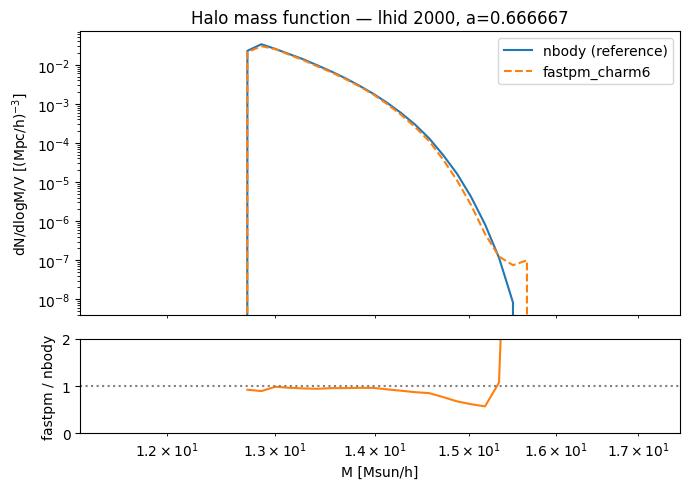

In [5]:
mn, *_ = load_halos(BASEDIR_NBODY,  LHID)
mf, *_ = load_halos(BASEDIR_FASTPM, LHID)

M_MIN = min(mn.min(), mf.min()) * 0.9
M_MAX = max(mn.max(), mf.max()) * 1.1
m_c,  hmf_n = mass_function(mn, V, m_min=M_MIN, m_max=M_MAX)
m_c2, hmf_f = mass_function(mf, V, m_min=M_MIN, m_max=M_MAX)
assert np.allclose(m_c, m_c2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.loglog(m_c, hmf_n, 'C0-',  label='nbody (reference)')
ax1.loglog(m_c, hmf_f, 'C1--', label='fastpm_charm6')
ax1.set_ylabel('dN/dlogM/V [(Mpc/h)$^{-3}$]')
ax1.set_title(f'Halo mass function — lhid {LHID}, a={A_TARGET}')
ax1.legend()

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(hmf_n > 0, hmf_f / hmf_n, np.nan)
ax2.semilogx(m_c, ratio, 'C1-')
ax2.axhline(1.0, color='grey', ls=':')
ax2.set_ylim(0, 2)
ax2.set_xlabel('M [Msun/h]')
ax2.set_ylabel('fastpm / nbody')
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_mass_function.jpg'), bbox_inches='tight')
plt.show()

## 3. Cumulative number density N(>M)/V

Integral form of the mass function; smoother and easier to read at the high-mass tail.

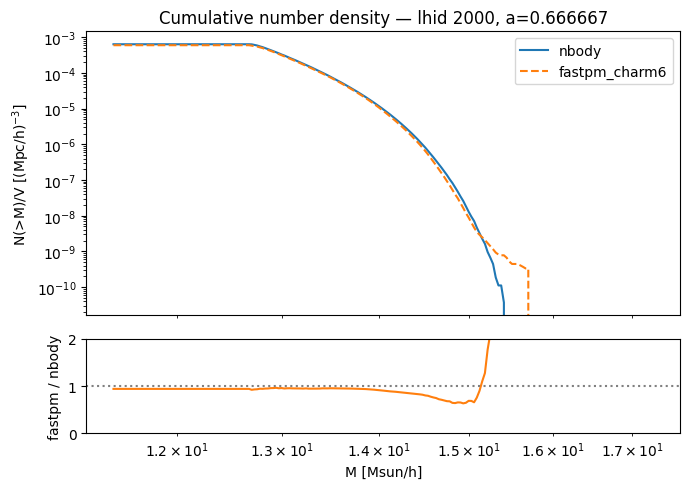

In [7]:
mn, *_ = load_halos(BASEDIR_NBODY,  LHID)
mf, *_ = load_halos(BASEDIR_FASTPM, LHID)

log_edges = np.linspace(np.log10(M_MIN), np.log10(M_MAX), 200)
m_bins = 10 ** log_edges

cum_n = np.array([(mn > m).sum() / V for m in m_bins])
cum_f = np.array([(mf > m).sum() / V for m in m_bins])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.loglog(m_bins, cum_n, 'C0-',  label='nbody')
ax1.loglog(m_bins, cum_f, 'C1--', label='fastpm_charm6')
ax1.set_ylabel('N(>M)/V [(Mpc/h)$^{-3}$]')
ax1.set_title(f'Cumulative number density — lhid {LHID}, a={A_TARGET}')
ax1.legend()

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_c = np.where(cum_n > 0, cum_f / cum_n, np.nan)
ax2.semilogx(m_bins, ratio_c, 'C1-')
ax2.axhline(1.0, color='grey', ls=':')
ax2.set_ylim(0, 2)
ax2.set_xlabel('M [Msun/h]')
ax2.set_ylabel('fastpm / nbody')
plt.tight_layout()
fig.savefig(join(FIGDIR, 'cumulative_number_density.jpg'), bbox_inches='tight')
plt.show()

## 4. Projected spatial distribution

Thin slab projection. Both should show the same cosmic web realization (same ICs);
filament positions should visually match between nbody and fastpm.

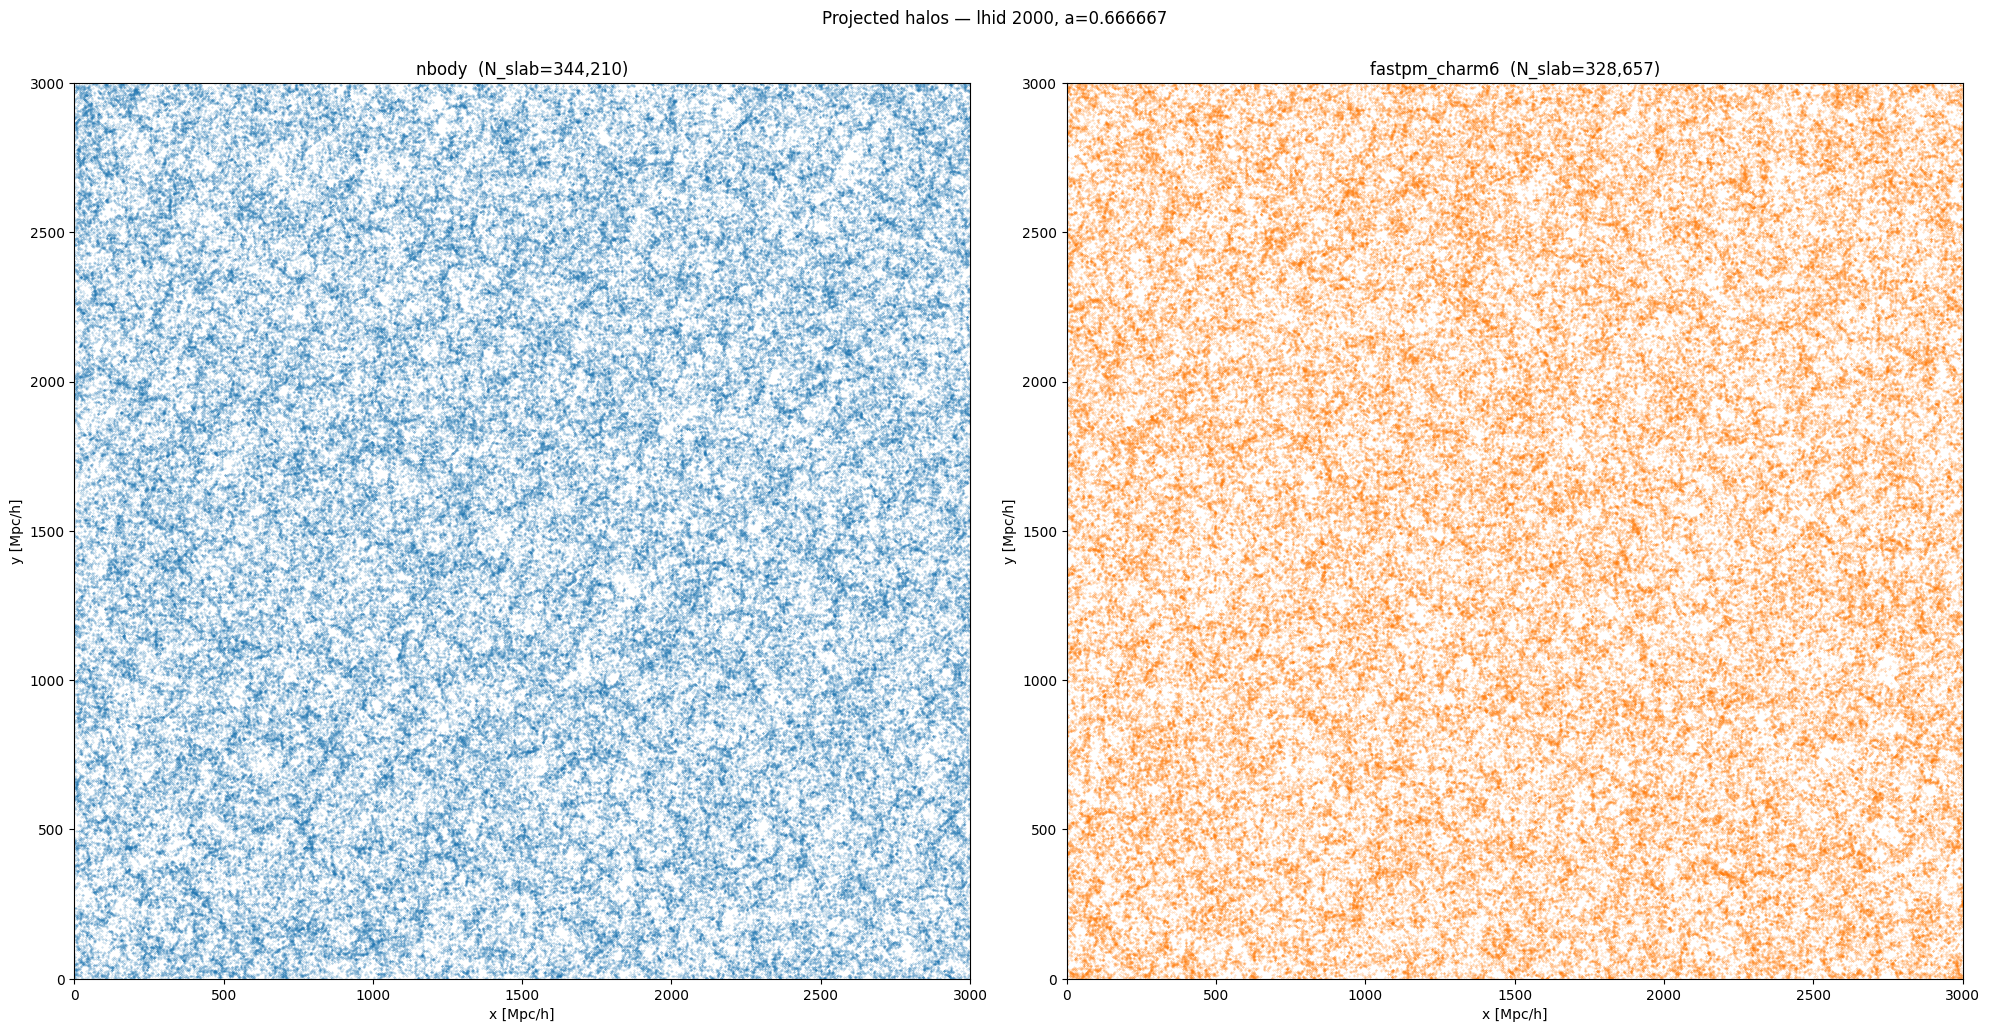

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, (label, basedir, color, ls) in zip(axes, SUITES):
    _, pos, *_ = load_halos(basedir, LHID)
    slab = np.abs(pos[:, 2] - L/2) < 0.01 * L   # thin 2% slab
    ax.scatter(pos[slab, 0], pos[slab, 1], s=0.1,
               alpha=0.4, color=color, rasterized=True)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_title(f'{label}  (N_slab={slab.sum():,d})')
    ax.set_xlabel('x [Mpc/h]')
    ax.set_ylabel('y [Mpc/h]')
    ax.set_aspect('equal')
plt.suptitle(f'Projected halos — lhid {LHID}, a={A_TARGET}', y=1.01)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_distribution.jpg'), bbox_inches='tight')
plt.show()

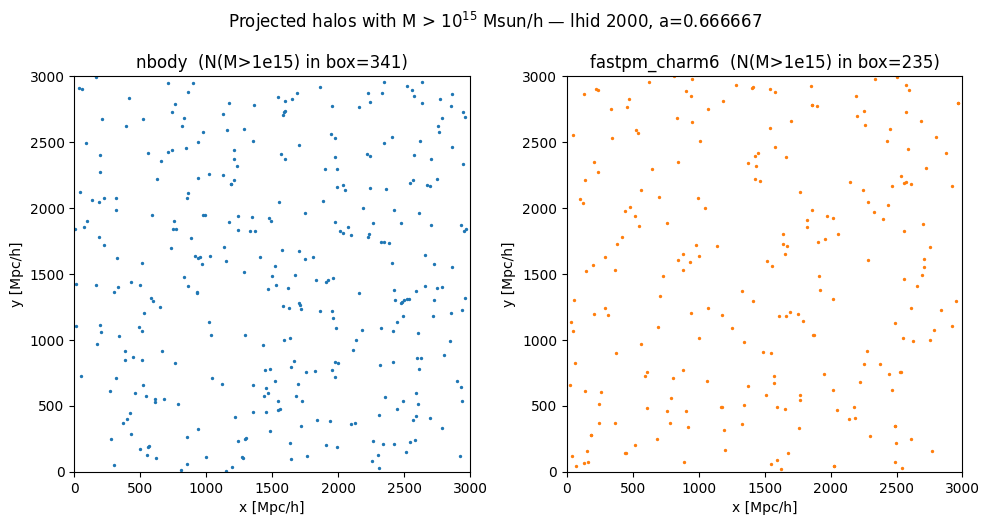

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (label, basedir, color, ls) in zip(axes, SUITES):
    mass, pos, *_ = load_halos(basedir, LHID)

    # mass cut: if catalog stores log10(M), use 15; otherwise use 1e15
    mcut = 15.0 if np.nanmedian(mass) < 100 else 1e15
    sel_m = mass > mcut

    slab = np.abs(pos[:, 2] - L/2) < L
    sel = slab & sel_m

    ax.scatter(pos[sel, 0], pos[sel, 1], s=2,
               alpha=1, color=color, rasterized=True)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_title(f'{label}  (N(M>1e15) in box={sel.sum():,d})')
    ax.set_xlabel('x [Mpc/h]')
    ax.set_ylabel('y [Mpc/h]')
    ax.set_aspect('equal')

plt.suptitle(
    f'Projected halos with M > 10$^{{15}}$ Msun/h — lhid {LHID}, a={A_TARGET}', y=1.01)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_distribution_mass_gt_1e15.jpg'),
            bbox_inches='tight')
plt.show()

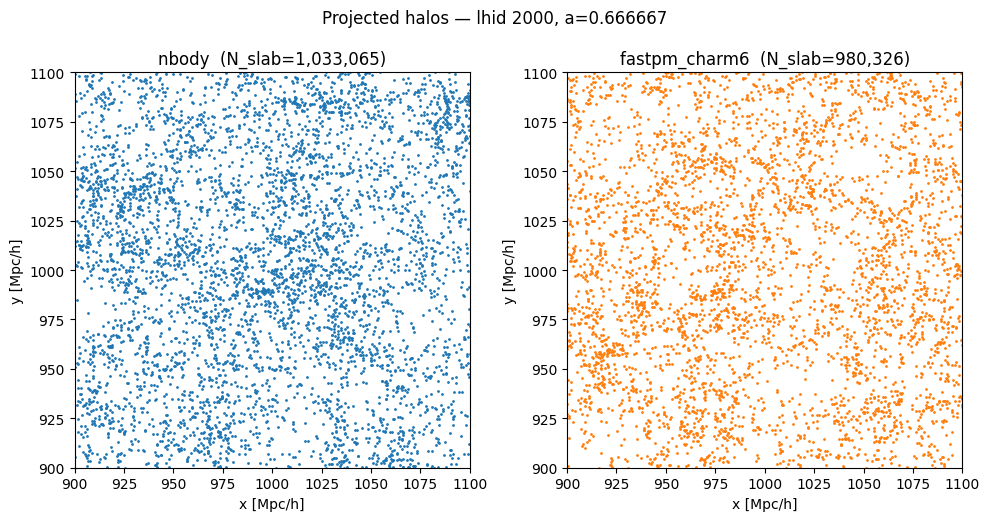

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, basedir, color, ls) in zip(axes, SUITES):
    _, pos, *_ = load_halos(basedir, LHID)
    slab = np.abs(pos[:, 2] - L/2) < 0.03 * L   # thin 2% slab
    ax.scatter(pos[slab, 0], pos[slab, 1], s=1,
               alpha=1, color=color, rasterized=True)
    ax.set_xlim(900, 1100)
    ax.set_ylim(900, 1100)
    ax.set_title(f'{label}  (N_slab={slab.sum():,d})')
    ax.set_xlabel('x [Mpc/h]')
    ax.set_ylabel('y [Mpc/h]')
    ax.set_aspect('equal')
plt.suptitle(f'Projected halos — lhid {LHID}, a={A_TARGET}', y=1.01)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_distribution_zoom.jpg'), bbox_inches='tight')
plt.show()

## 5. Velocity PDFs

Per-component velocity distributions should be zero-mean, roughly Gaussian, and
similar between nbody and fastpm (same ICs → same large-scale velocity field).

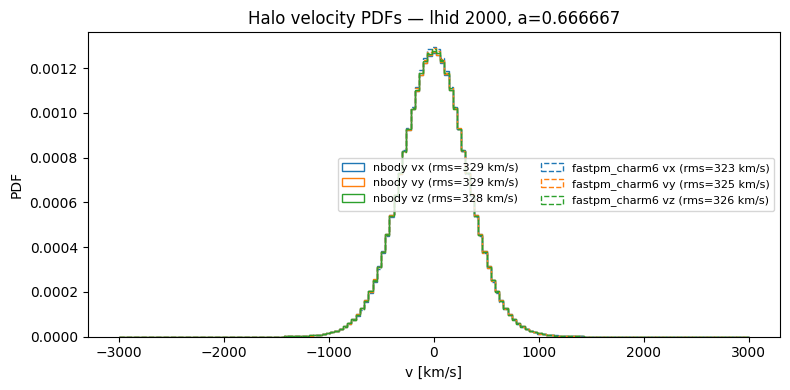

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(-3000, 3000, 150)

for label, basedir, _, ls in SUITES:
    _, _, vel, *_ = load_halos(basedir, LHID)
    for i, c in enumerate('xyz'):
        ax.hist(
            vel[:, i],
            bins=bins,
            histtype='step',
            density=True,
            color=f'C{i}',      # x/y/z component color
            ls=ls,              # suite style: solid/dashed
            label=f'{label} v{c} (rms={vel[:, i].std():.0f} km/s)'
        )

ax.set_xlabel('v [km/s]')
ax.set_ylabel('PDF')
ax.set_title(f'Halo velocity PDFs — lhid {LHID}, a={A_TARGET}')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_velocity_pdfs.jpg'), bbox_inches='tight')
plt.show()

## 6. Concentration PDFs

NFW concentration should be positive and peaked in the range 5–15.
Differences between nbody and fastpm here are expected (different halo finders
or fitting procedures may assign concentrations differently).

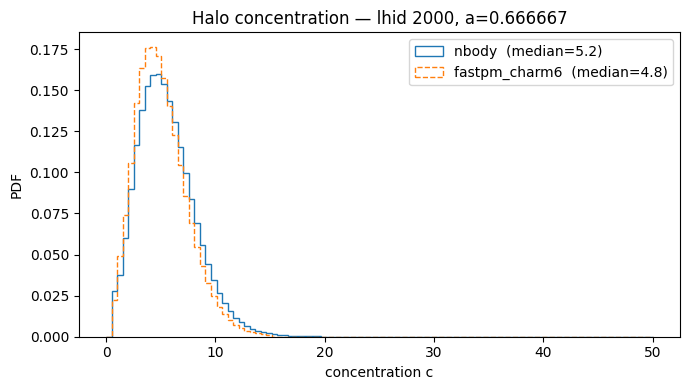

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 50, 100)
for label, basedir, color, ls in SUITES:
    _, _, _, conc, _ = load_halos(basedir, LHID)
    ax.hist(conc, bins=bins, histtype='step', density=True,
            color=color, ls=ls, label=f'{label}  (median={np.median(conc):.1f})')
ax.set_xlabel('concentration c')
ax.set_ylabel('PDF')
ax.set_title(f'Halo concentration — lhid {LHID}, a={A_TARGET}')
ax.legend()
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_concentration_pdfs.jpg'), bbox_inches='tight')
plt.show()

## 7. Halo power spectrum vs CAMB linear theory

Halos are NGP-painted onto a mesh; shot noise (L³/N_halos) is subtracted.
N-body (solid) is the reference; FastPM (dashed) should match at large scales
and may deviate at small scales. The grey dotted line is CAMB linear matter P(k);
halo P(k) lies above it at large scales by ~b². The lower panel shows the ratio
FastPM / N-body — deviations from 1 quantify emulator error.

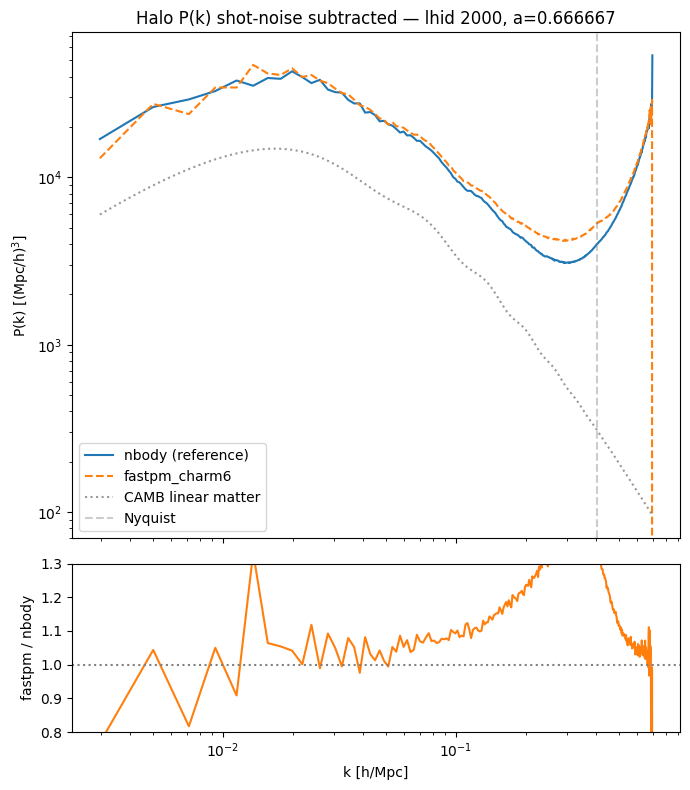

In [13]:
import Pk_library as PKL
from cmass.nbody.tools import get_camb_pk

N_MESH = 384


def halo_pk(pos, boxsize, n_mesh, threads=4):
    """NGP-paint halo positions onto a mesh and compute P(k)."""
    delta, _ = np.histogramdd(pos, bins=n_mesh, range=[(0, boxsize)] * 3)
    delta = delta.astype(np.float32)
    delta /= delta.mean()
    delta -= 1.0
    pk_obj = PKL.Pk(delta, float(boxsize), axis=0, MAS='NGP',
                    verbose=False, threads=threads)
    return pk_obj.k3D, pk_obj.Pk[:, 0]


z = 1.0 / A_TARGET - 1.0
cosmo = load_cosmo(BASEDIR_NBODY, LHID)

_, posn, *_ = load_halos(BASEDIR_NBODY,  LHID)
_, posf, *_ = load_halos(BASEDIR_FASTPM, LHID)

kn, pkn = halo_pk(posn, L, N_MESH)
kf, pkf = halo_pk(posf, L, N_MESH)
shot_n = L**3 / len(posn)
shot_f = L**3 / len(posf)

kcamb, pklin = get_camb_pk(kn.astype(float), *cosmo, z=z)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.loglog(kn, pkn - shot_n, 'C0-',  label='nbody (reference)')
ax1.loglog(kf, pkf - shot_f, 'C1--', label='fastpm_charm6')
ax1.loglog(kcamb, pklin, color='grey', ls=':',
           alpha=0.8, label='CAMB linear matter')
ax1.axvline(np.pi * N_MESH / L, color='grey',
            ls='--', alpha=0.4, label='Nyquist')
ax1.set_ylabel('P(k) [(Mpc/h)$^3$]')
ax1.set_title(f'Halo P(k) shot-noise subtracted — lhid {LHID}, a={A_TARGET}')
ax1.legend()

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(pkn - shot_n > 0,
                     (pkf - shot_f) / (pkn - shot_n),
                     np.nan)
ax2.semilogx(kn, ratio, 'C1-')
ax2.axhline(1.0, color='grey', ls=':')
ax2.set_ylim(0.8, 1.3)
ax2.set_xlabel('k [h/Mpc]')
ax2.set_ylabel('fastpm / nbody')
plt.tight_layout()
fig.savefig(join(FIGDIR, 'halo_power_spectra.jpg'), bbox_inches='tight')
plt.show()